# **XPM Identity Operator**

In [1]:
# general imports
import numpy as np
import matplotlib.pyplot as plt

# ml imports
import torch
import torch.nn.functional as F
from tqdm import tqdm

# import module
from nlse import *

Using device: cpu


In [2]:
# Device configuration for GPU support
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cpu


## **Universal Parameters**

In [3]:
# define simulation parameters used in inverse design
Lz = 1e-3               # Propagation distance in km (1cm = 1e-5)
Nz = 100               # Number of steps in z
dz = Lz / Nz            # Step size in z
Lt = 10                  # Temporal window size
Nt = 2048               # Number of temporal points
dt = Lt / Nt
N_modes = 100

# define medium parameters
beta2_j = -10           # anomalous GVD region
beta2_k = -10           # anomalous GVD region
gamma_j = 1
gamma_k = 1

# define pulse parameters
tau = 0.1               # temporal width of the pulse = 100 fs - also, characteristic time of Hermite-Gauss basis used in simulation

In [4]:
# define HG basis
t = torch.linspace(-Lt/2, Lt/2, Nt, dtype=torch.float32)
hg_basis = get_hg_basis(N_modes, t, tau)

Precomputed 100 HG basis functions on grid of 2048 points on device cpu


In [5]:
# for plotting
plot_percent = 0.2  # Show central 30% of the data

# Calculate the indices for the central portion
total_points = len(t)
center_points = int(total_points * plot_percent)
start_idx = (total_points - center_points) // 2
end_idx = start_idx + center_points

## **Useful Functions**

In [6]:
def strong_soliton(t, beta2_k, gamma_k, tau):
    """Create the strong pulse (A_k) based on the soliton parameters."""
    # calculate secondary parameters
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    
    # Define strong pulse waveform
    Ain_k = a_2 * torch.cosh(t / tau)**(-1)

    return Ain_k

## **Define Training Batches**

Precomputed 16 HG basis functions on grid of 2048 points on device cpu


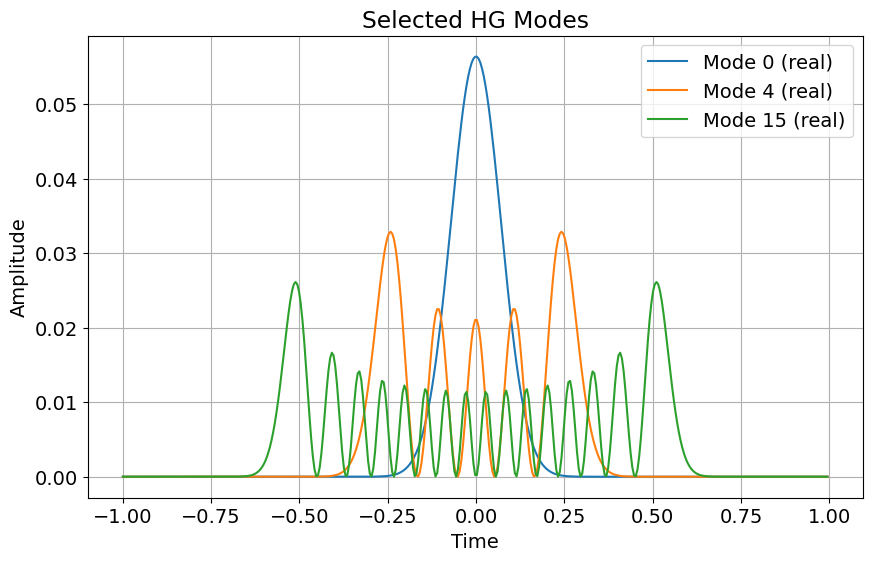

torch.Size([16, 2048])


In [7]:
# define number of modes to simulate and thus the batch size
B = 16
amplitude_downscale = 1e-1

# get batch of pulses
x = get_hg_basis(B, t, tau) * amplitude_downscale # inputs
y = x.clone().detach() # labels

# plot
modes_to_plot = [0, 4, 15]

plt.figure(figsize=(10, 6))
for mode in modes_to_plot:
    plt.plot(t[start_idx:end_idx], (torch.abs(x[mode])**2)[start_idx:end_idx], label=f'Mode {mode} (real)')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Selected HG Modes')
plt.legend()
plt.grid(True)
plt.show()

print(x.shape)

## **Training**

### Training Parameters

In [8]:
# define simulation parameters
mask_percent = 0.6 # size of the unpenalized region in percent of the total temporal window
m = 8 # number of slices to check for penalty
w_mse = 1e4
w_pen = 1e3 # penalty weight
lr = 1e-1
N_train = 10

### Intialization

In [9]:
""" define inputs """
# define input strong pulse
A_strong = strong_soliton(t, beta2_k, gamma_k, tau)
A_strong_hg = time_to_hg(A_strong, hg_basis, dt)
theta = torch.nn.Parameter(A_strong_hg.clone().detach().requires_grad_(True)) # our controllable parameters - the coefficients of A_strong in the HG basis

""" define training functions and objects """
# define penalty mask (takes values of 1 where the wave is not allowed to have nonzero values)
penalty = torch.zeros_like(t)
penalty[:int(Nt/2-Nt*mask_percent/2)] = 1
penalty[int(Nt/2+Nt*mask_percent/2):] = 1
mask = 1 - penalty
iters = np.linspace(0, Nz-1, m).astype(int)

# define loss function
def loss_function(A_j_evolution, A_k_evolution):
    
    # mse loss 
    mse_loss = F.mse_loss(torch.abs(A_j_evolution[:, :, -1])**2, torch.abs(y)**2)

    pen_loss = 0.0
    zeros = torch.zeros(B, Nt, dtype=torch.float32)
    # penalization loss - to enforce none of the waves to stray outside the simulation bounds
    for i in iters:  
        pen_loss = pen_loss + F.mse_loss(torch.abs(A_k_evolution[:, :, i]*penalty)**2, zeros) 

    return w_mse * mse_loss, w_pen * pen_loss

# define forward pass
def forward(theta, hg_basis): # in-> Ain_k, out-> A_evolution[:, -1]
    Ain_k = hg_to_time(theta, hg_basis)
    return split_step_fourier_xpm_batch(x, Ain_k, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)

# initialize optimizer
optimizer = torch.optim.Adam([theta], lr=lr)


print(f"Optimizing HG basis coefficient theta of size {theta.shape[0]}")


Optimizing HG basis coefficient theta of size 100


### **Training**

In [10]:
losses_mse = []
losses_pen = []
losses = []
for i in tqdm(range(N_train), desc="Training"):
    optimizer.zero_grad()
    A_j_evolution, A_k_evolution = forward(theta, hg_basis)
    loss_mse, loss_pen = loss_function(A_j_evolution, A_k_evolution)
    loss = loss_mse + loss_pen
    loss.backward()
    optimizer.step()

    # save and print the loss every {n} iterations
    if i % 1 == 0:
        losses_mse.append(loss_mse.item())
        losses_pen.append(loss_pen.item())
        losses.append(loss.item())

Training: 100%|██████████| 10/10 [00:47<00:00,  4.75s/it]


### **Evaluation**

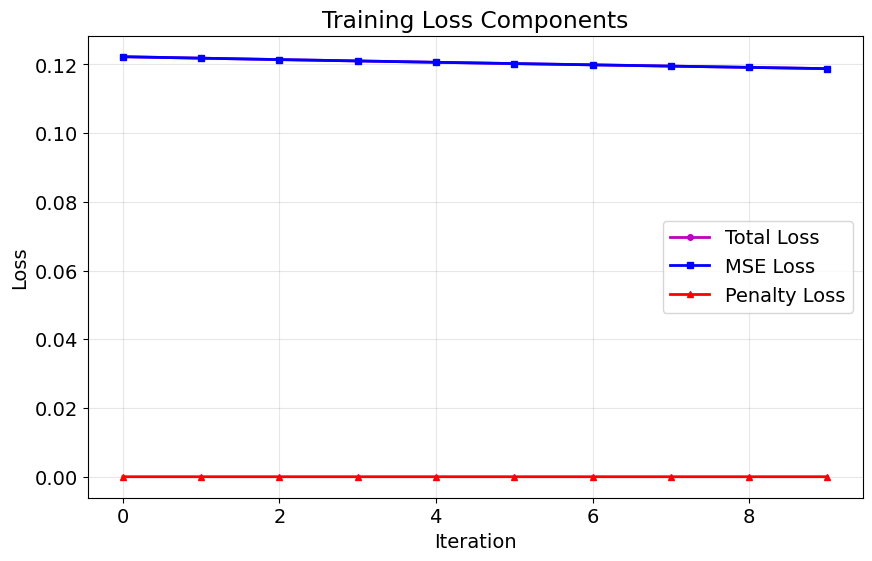

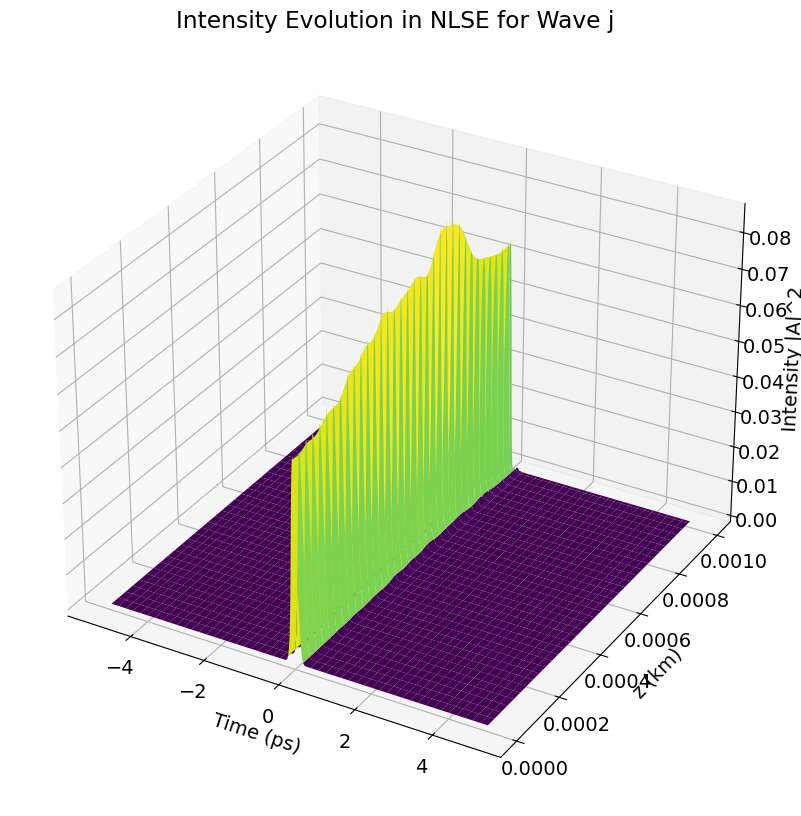

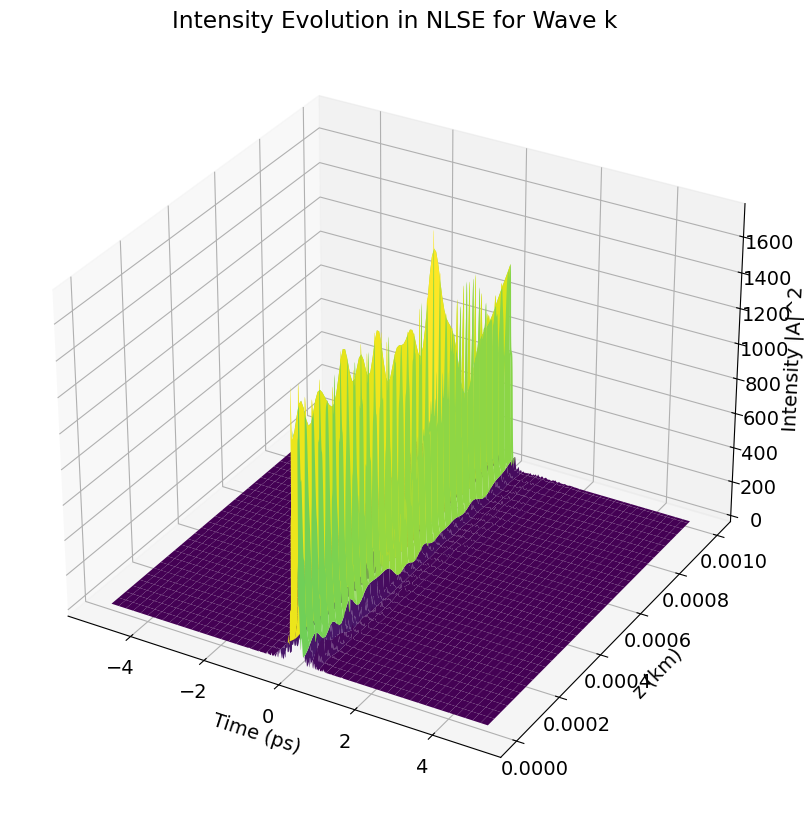

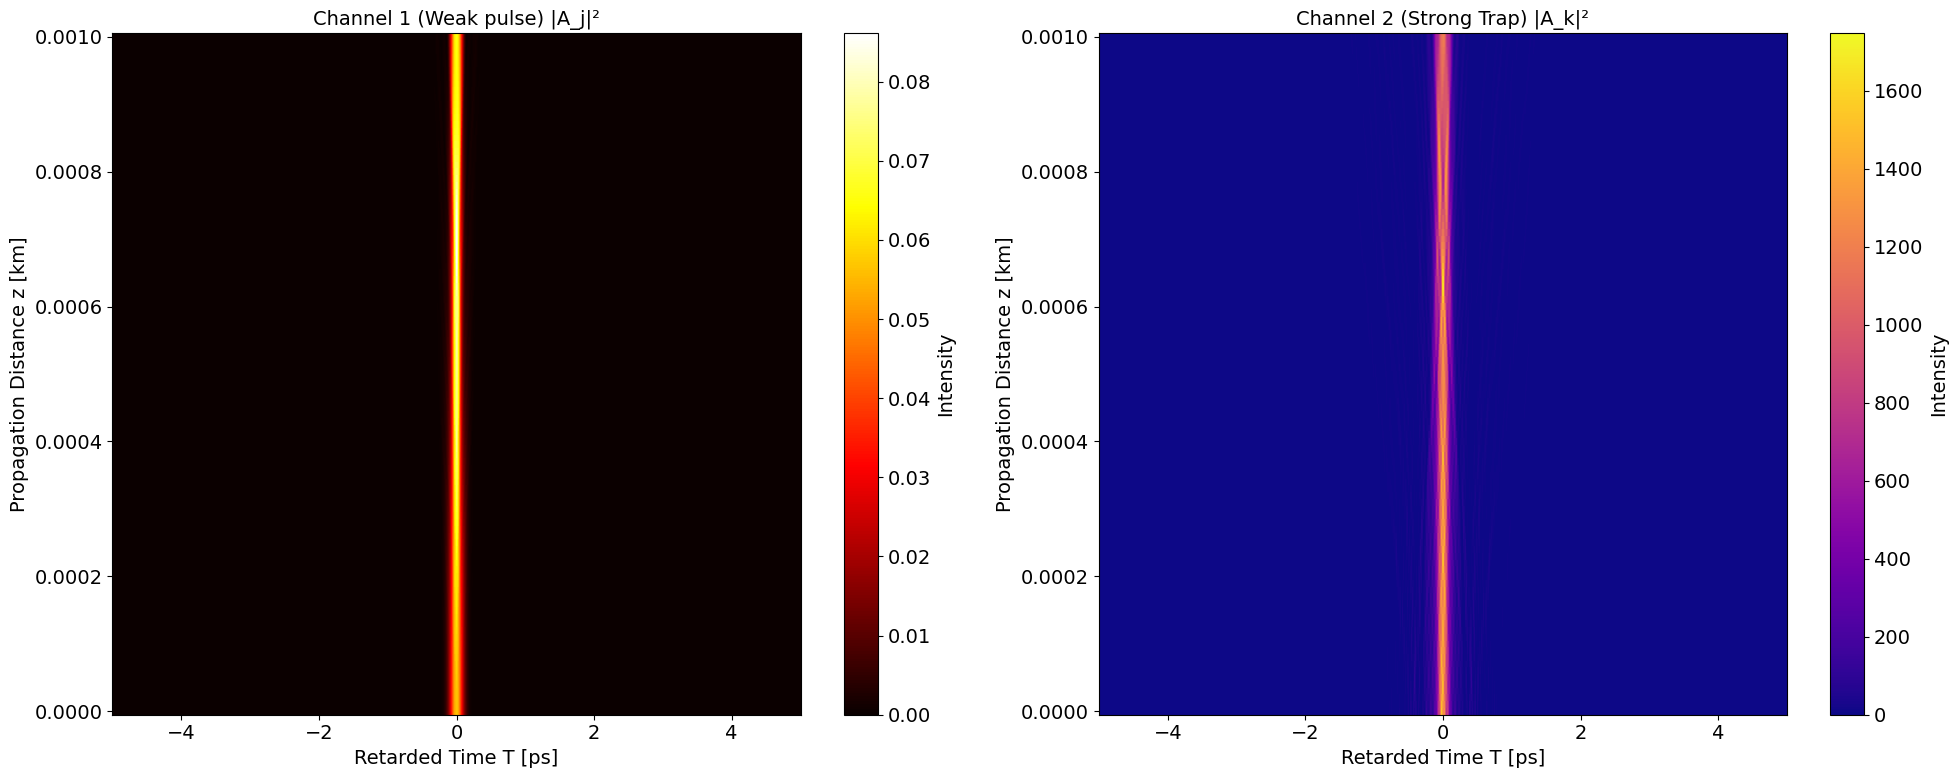

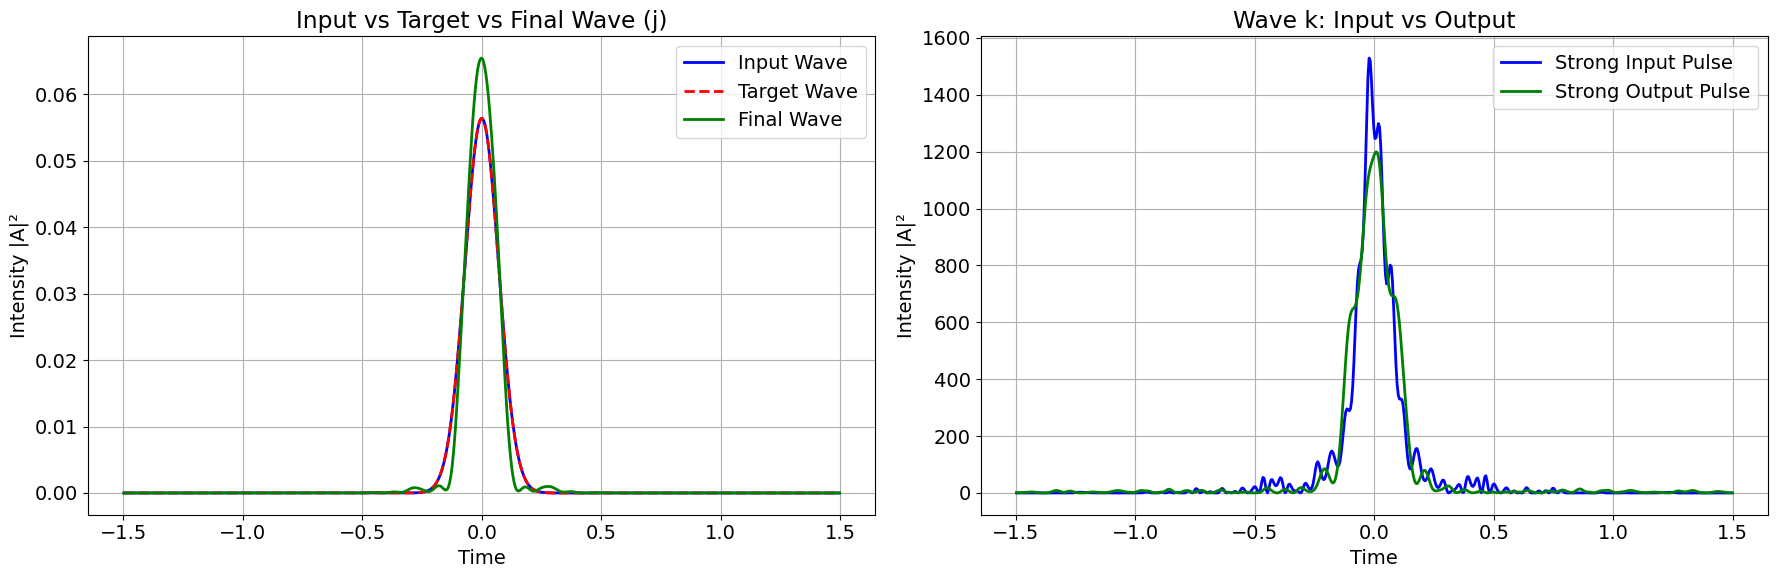

In [11]:
# plot the loss
plt.figure(figsize=(10, 6))
plt.plot(losses, color='m', marker="o", label='Total Loss', linewidth=2, markersize=4)
plt.plot(losses_mse, color='b', marker="s", label='MSE Loss', linewidth=2, markersize=4)
plt.plot(losses_pen, color='r', marker="^", label='Penalty Loss', linewidth=2, markersize=4)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Loss Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

mode_nr = 0

# plot the evolution of the waves
plot_intensity_evolution(A_j_evolution[mode_nr, :, :], t, Lz, Nz, wave_name='Wave j')
plot_intensity_evolution(A_k_evolution[mode_nr, :, :], t, Lz, Nz, wave_name='Wave k')
plot_cowave_evolution(A_j_evolution[mode_nr, :, :].detach().clone(), A_k_evolution[mode_nr, :, :].detach().clone(), t, Lz, Nz)

# plot the target vs the final wave
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

plot_percent = 0.3  # Show central 30% of the data

# Calculate the indices for the central portion
total_points = len(t)
center_points = int(total_points * plot_percent)
start_idx = (total_points - center_points) // 2
end_idx = start_idx + center_points

# Extract central portion of time and data
t_center = t[start_idx:end_idx]

ax1.plot(t_center, np.abs(x[mode_nr].detach().cpu().numpy())[start_idx:end_idx]**2, 'b-', label='Input Wave', linewidth=2)
ax1.plot(t_center, np.abs(y[mode_nr].detach().cpu().numpy())[start_idx:end_idx]**2, 'r--', label='Target Wave', linewidth=2)
ax1.plot(t_center, np.abs(A_j_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx:end_idx]**2, 'g-', label='Final Wave', linewidth=2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Intensity |A|²')
ax1.set_title('Input vs Target vs Final Wave (j)')
ax1.legend()
ax1.grid()

# Second subplot: Wave k first and last
ax2.plot(t_center, np.abs(A_k_evolution[mode_nr, :, 0].detach().cpu().numpy())[start_idx:end_idx]**2, 'b-', label='Strong Input Pulse', linewidth=2)
ax2.plot(t_center, np.abs(A_k_evolution[mode_nr, :, -1].detach().cpu().numpy())[start_idx:end_idx]**2, 'g-', label='Strong Output Pulse', linewidth=2)
ax2.set_xlabel('Time')
ax2.set_ylabel('Intensity |A|²')
ax2.set_title('Wave k: Input vs Output')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()
